In [148]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates

import phik
from phik import resources
from phik.binning import bin_data
from phik.report import plot_correlation_matrix


PROJECT_ROOT = Path.cwd().parent if (Path.cwd().parent / "pyproject.toml").exists() else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from src.config import HF_REPO_ID

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [149]:
df_data = pd.read_parquet(
    f"hf://datasets/{HF_REPO_ID}/interim/safra/producao_feijao_tons.parquet",
    storage_options={'revision': 'main'}
)


In [150]:
# df_data.info()

Cada linha representa a produção em toneladas por safra e por mês de cada estado. Os casos de produção zero indicam que não houve produção na respectiva safra.

Meses convertidos em números de 1.0 a 12.0.



In [151]:
pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1500)
pd.set_option("display.colheader_justify", "center")
pd.set_option("display.float_format","{:.2f}".format)
# display(df_data)

In [152]:
prod_anual_estado = duckdb.sql("""
                               SELECT uf, SUM(quantidade_tons) AS total
                               FROM df_data
                               GROUP BY uf
                               ORDER BY total DESC
                               """).df()

pd.set_option("display.max_rows", None)
# display(prod_anual_estado)

In [153]:
prod_anual = duckdb.sql("""
                               SELECT ano, SUM(quantidade_tons) AS total
                               FROM df_data
                               GROUP BY ano
                               ORDER BY total DESC;
                               """).df()

pd.set_option("display.max_rows", None)
# display(prod_anual)

Janela dos dados

In [154]:
janela_dados = duckdb.sql("""
                               SELECT
                               MIN(ano * 100 + mes) AS inicio,
                               MAX(ano * 100 + mes) AS fim
                               FROM df_data;
                               """).df()

display(janela_dados)

,inicio,fim
0,200609,202607


## Plotagens

In [155]:
distribuicao = duckdb.sql("""
                               SELECT ano AS ANO, ROUND(SUM(quantidade_tons)) AS PRODUÇÃO
                               FROM df_data
                               GROUP BY ano
                               ORDER BY ano DESC
                               """).df()

# display(distribuicao)

A 

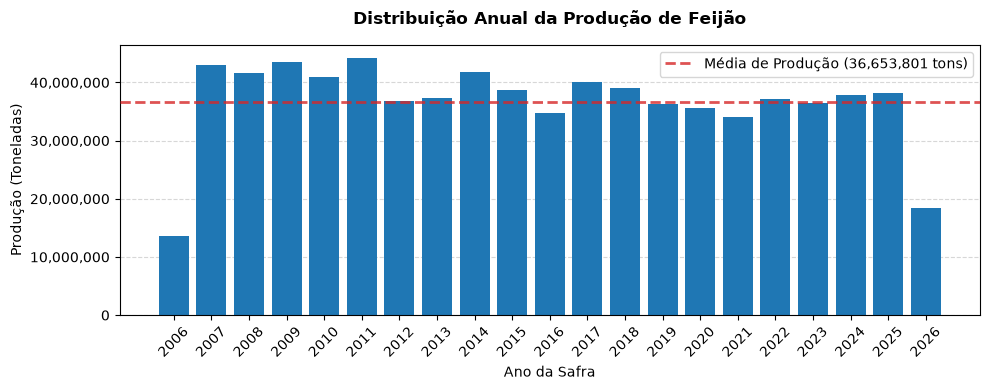

In [156]:
prod_anual_media = distribuicao["PRODUÇÃO"].mean()

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    distribuicao["ANO"], 
    distribuicao["PRODUÇÃO"], 
    color='#1f77b4',
    zorder=2
)

ax.axhline(
    y=prod_anual_media, 
    color='#d62728', 
    linestyle="--", 
    linewidth=2, 
    alpha=0.8,
    label=f'Média de Produção ({prod_anual_media:,.0f} tons)',
    zorder=3
)

ax.set_xticks(distribuicao["ANO"])
ax.tick_params(axis='x', rotation=45) 

ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=1)

ax.set_title("Distribuição Anual da Produção de Feijão", fontweight='bold', pad=15)
ax.set_ylabel("Produção (Toneladas)")
ax.set_xlabel("Ano da Safra")

ax.legend()

plt.tight_layout()
plt.show()




Maiores produtores médios.

,Região,Produção (Toneladas)
0,Sul,231973732.00
1,Sudeste,191776337.00
2,Nordeste,176295275.00


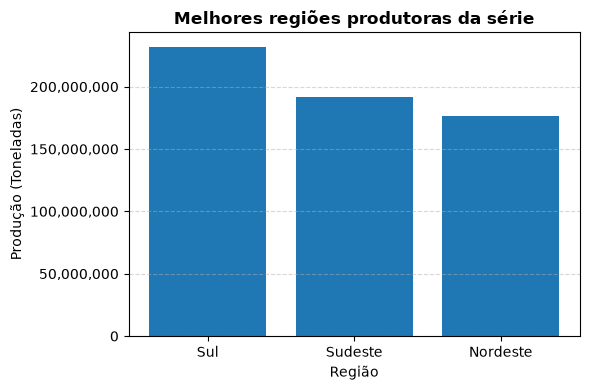

In [157]:
prod_media_regiao = duckdb.sql("""
                           SELECT 
                            regiao AS "Região", 
                            ROUND(SUM(quantidade_tons)) AS "Produção (Toneladas)",
                           FROM df_data
                           GROUP BY regiao
                           ORDER BY "Produção (Toneladas)" DESC
                           LIMIT 3;
                           """).df()

display(prod_media_regiao)

fig, ax = plt.subplots(figsize=(6,4)) 

ax.bar(
    prod_media_regiao["Região"],
    prod_media_regiao["Produção (Toneladas)"], 
    # prod_media_regiao["Produção Média(Toneladas)"],
    color='#1f77b4'
)

ax.set_xticks(prod_media_regiao["Região"])
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.set_title("Melhores regiões produtoras da série", fontweight='bold')
ax.set_ylabel("Produção (Toneladas)")
ax.set_xlabel("Região")

ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

plt.tight_layout()
plt.show()

,Estado,Produção (Toneladas)
0,parana,175777768.00
1,minas_gerais,130343347.00
2,goias,74215578.00


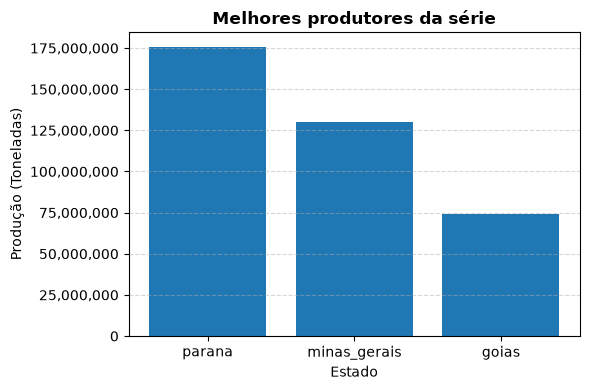

In [158]:
prod_media_estado = duckdb.sql("""
                           SELECT 
                           uf AS "Estado", 
                           ROUND(SUM(quantidade_tons)) AS "Produção (Toneladas)"
                           FROM df_data
                           GROUP BY uf
                           ORDER BY "Produção (Toneladas)" DESC
                           LIMIT 3;
                           """).df()

display(prod_media_estado)

fig, ax = plt.subplots(figsize=(6,4)) 

ax.bar(
    prod_media_estado["Estado"], 
    prod_media_estado["Produção (Toneladas)"],
    color='#1f77b4' # Azul clássico
)

ax.set_xticks(prod_media_estado["Estado"])
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.set_title("Melhores produtores da série", fontweight='bold')
ax.set_ylabel("Produção (Toneladas)")
ax.set_xlabel("Estado")

ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

plt.tight_layout()
plt.show()

,Mês da Safra,Produção Total (Toneladas)
0,1,68020583.00
1,2,67320349.00
2,3,66912976.00


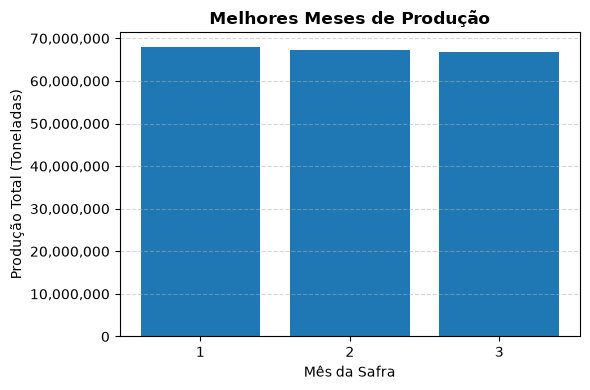

In [159]:
melhores_safras_mes = duckdb.sql("""
                           SELECT mes AS "Mês da Safra", ROUND(SUM(quantidade_tons)) AS "Produção Total (Toneladas)"
                           FROM df_data
                           GROUP BY mes
                           ORDER BY "Produção Total (Toneladas)" DESC
                           LIMIT 3;
                           """).df()
display(melhores_safras_mes)

fig, ax = plt.subplots(figsize=(6,4)) 

ax.bar(
    melhores_safras_mes["Mês da Safra"], 
    melhores_safras_mes["Produção Total (Toneladas)"],
    color='#1f77b4'
)

ax.set_xticks(melhores_safras_mes["Mês da Safra"])
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.set_title("Melhores Meses de Produção", fontweight='bold')
ax.set_ylabel("Produção Total (Toneladas)")
ax.set_xlabel("Mês da Safra")

ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

plt.tight_layout()
plt.show()

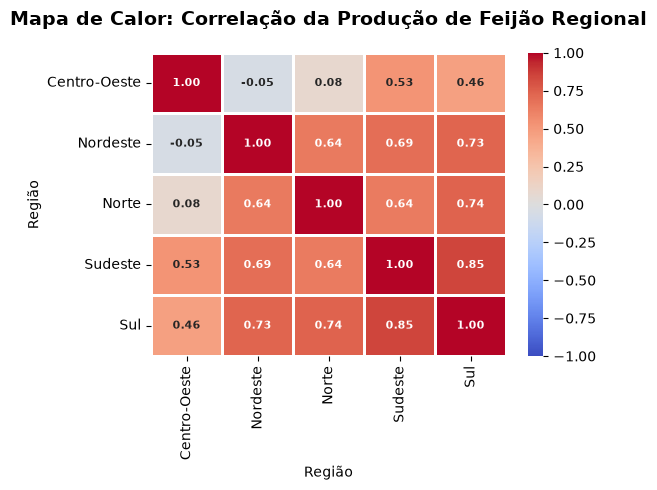

In [160]:
prod_regiao = duckdb.sql("""
                        SELECT 
                            ano AS "Ano",
                            regiao AS "Região",
                            SUM(quantidade_tons) AS "Produção"
                        FROM df_data
                        GROUP BY ano, regiao;
                        """).df()

prod_regiao = prod_regiao.pivot(
    index='Ano', 
    columns='Região', 
    values='Produção'
    )
correlacao_regional = prod_regiao.corr()

plt.figure(figsize=(6, 5))

sns.heatmap(
    correlacao_regional, 
    cmap="coolwarm", 
    vmin=-1, vmax=1, 
    linewidths=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size":8, "weight":"bold" }
)

plt.title(
    "Mapa de Calor: Correlação da Produção de Feijão Regional", 
    pad=20, 
    fontsize=14, 
    fontweight='bold'
    )
plt.xlabel("Região")
plt.ylabel("Região")

plt.tight_layout()
plt.show()

Este gráfico demonstra que as regiões litorâneas tem maior correlação.

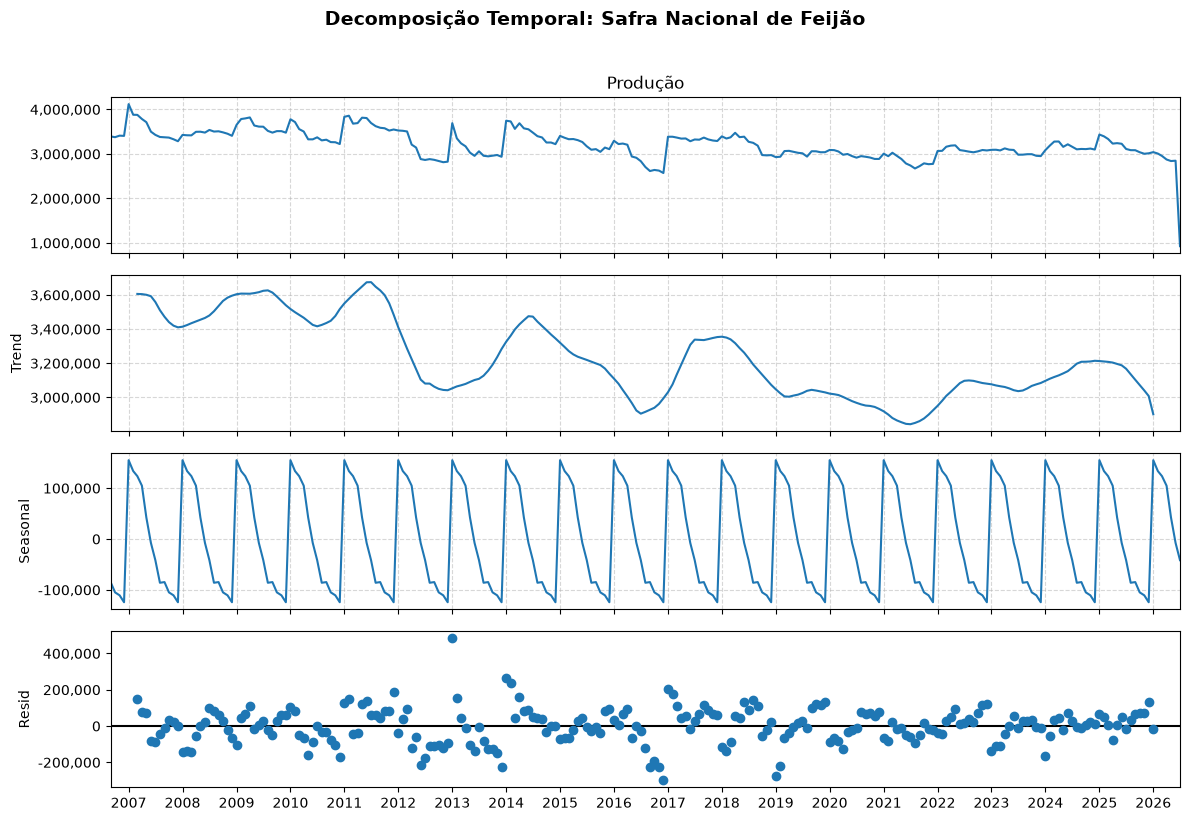

In [161]:
serie = duckdb.sql("""
                        SELECT
                            MAKE_DATE(ano, mes, 1) AS "Data",
                            SUM(quantidade_tons) AS "Produção"
                        FROM df_data
                        GROUP BY ano, mes
                        ORDER BY Data ASC;                          
                          """).df()

serie.set_index('Data', inplace=True)

decomposicao = seasonal_decompose(
    serie["Produção"],
    model="additive", 
    period = 12,
    )

fig=decomposicao.plot()
fig.set_size_inches(12,8)
fig.suptitle(
    "Decomposição Temporal: Safra Nacional de Feijão",
    fontweight='bold', 
    fontsize=14, 
    y=1.02
    )

axes = fig.get_axes()
for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_formatter(lambda x, p: format(int(x), ","))

plt.tight_layout()
plt.grid()
plt.show()

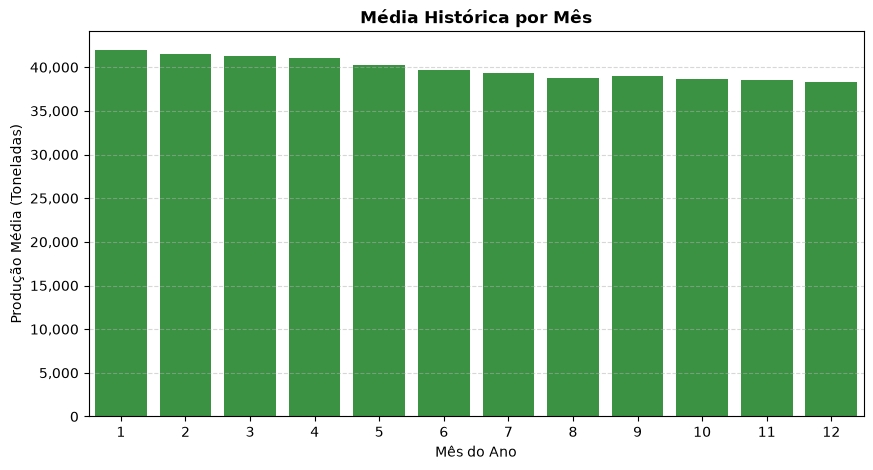

In [162]:
sazonalidade_mensal = duckdb.sql("""
    SELECT 
        mes AS "Mês", 
        ROUND(AVG(quantidade_tons)) AS "Produção Média"
    FROM df_data
    GROUP BY mes
    ORDER BY mes ASC;
""").df()

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=sazonalidade_mensal, 
    x="Mês", 
    y="Produção Média", 
    color="#2ca036",
    ax=ax
)

ax.set_title("Média Histórica por Mês", fontweight='bold')
ax.set_ylabel("Produção Média (Toneladas)")
ax.set_xlabel("Mês do Ano")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

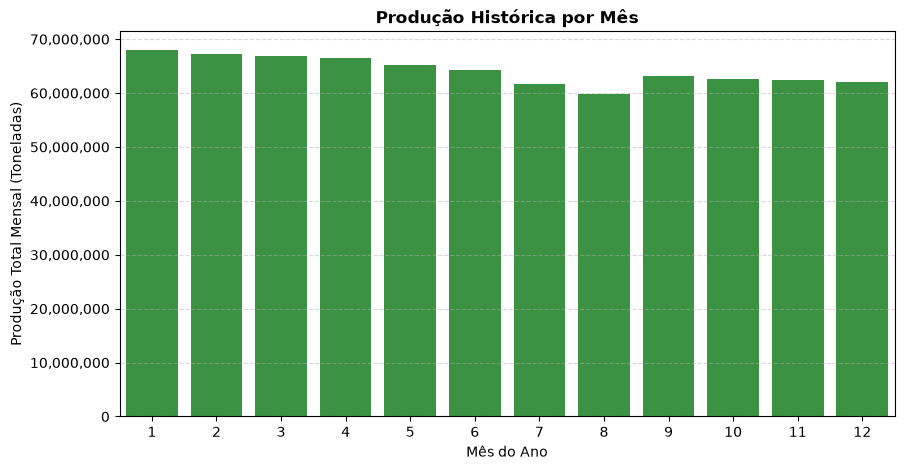

In [163]:
total_mensal = duckdb.sql("""
    SELECT 
        mes AS "Mês", 
        ROUND(SUM(quantidade_tons)) AS "Produção Total"
    FROM df_data
    GROUP BY mes
    ORDER BY mes ASC;
""").df()

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=total_mensal, 
    x="Mês", 
    y="Produção Total", 
    color="#2ca036",
    ax=ax
)

ax.set_title("Produção Histórica por Mês", fontweight='bold')
ax.set_ylabel("Produção Total Mensal (Toneladas)")
ax.set_xlabel("Mês do Ano")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

>Adicionar area plantada, rendimento para a melhora na analise da produção.

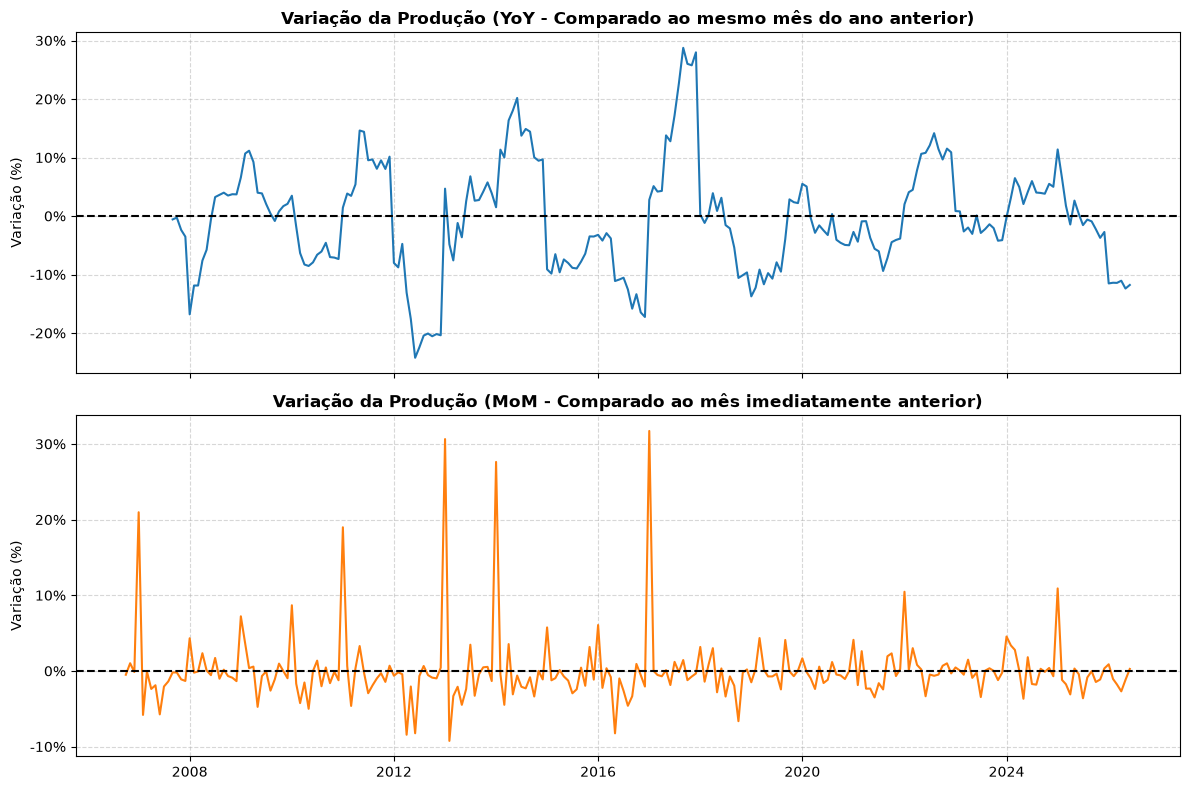

In [164]:
linha_do_tempo = duckdb.sql("""
    SELECT 
        MAKE_DATE(ano, mes, 1) AS data, 
        SUM(quantidade_tons) AS producao
    FROM df_data
    GROUP BY ano, mes
    ORDER BY data ASC;
""").df()

linha_do_tempo.set_index('data', inplace=True)
linha_do_tempo = linha_do_tempo.loc[:'2026-06-01']

linha_do_tempo['variacao_mom'] = linha_do_tempo['producao'].pct_change(1) * 100
linha_do_tempo['variacao_yoy'] = linha_do_tempo['producao'].pct_change(12) * 100

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(linha_do_tempo.index, linha_do_tempo['variacao_yoy'], color='#1f77b4', linewidth=1.5)
ax[0].axhline(0, color='black', linewidth=1.5, linestyle='--')
ax[0].set_title("Variação da Produção (YoY - Comparado ao mesmo mês do ano anterior)", fontweight='bold')
ax[0].set_ylabel("Variação (%)")
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}%'))

ax[1].plot(linha_do_tempo.index, linha_do_tempo['variacao_mom'], color='#ff7f0e', linewidth=1.5)
ax[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
ax[1].set_title("Variação da Produção (MoM - Comparado ao mês imediatamente anterior)", fontweight='bold')
ax[1].set_ylabel("Variação (%)")
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}%'))

plt.tight_layout()
plt.show()

interval columns not set, guessing: ['ano', 'mes', 'safra', 'quantidade_tons']


,ano,mes,uf,safra,quantidade_tons,regiao
ano,1.00,0.10,0.00,0.00,0.20,0.00
mes,0.10,1.00,0.00,0.00,0.00,0.00
uf,0.00,0.00,1.00,0.00,0.75,1.00
safra,0.00,0.00,0.00,1.00,0.25,0.00
quantidade_tons,0.20,0.00,0.75,0.25,1.00,0.58
regiao,0.00,0.00,1.00,0.00,0.58,1.00


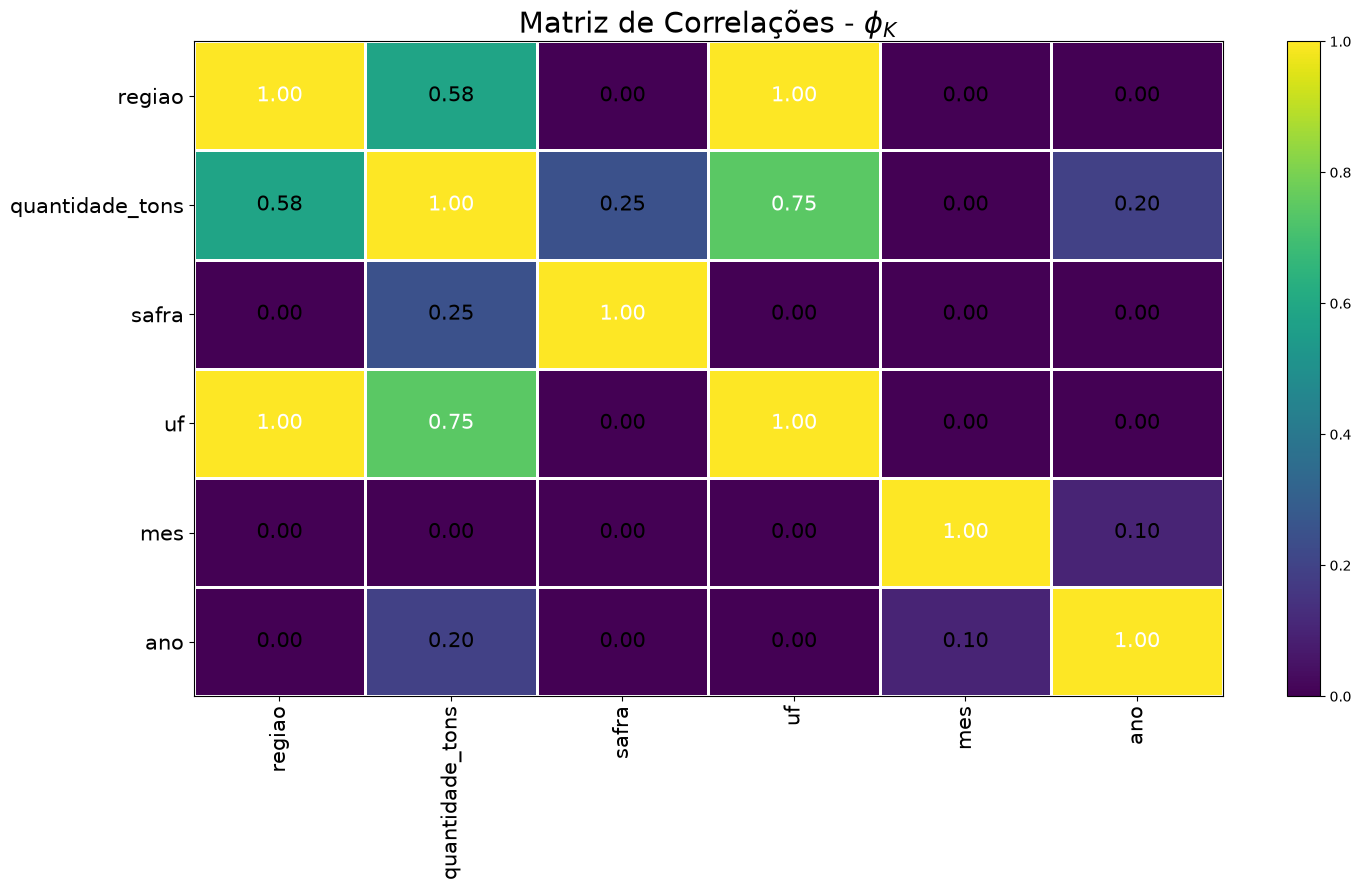

In [166]:
signifcanciaCorrelacoes = df_data.phik_matrix()
display(signifcanciaCorrelacoes)

plot_correlation_matrix(
    signifcanciaCorrelacoes.values,
    x_labels = signifcanciaCorrelacoes.columns,
    y_labels = signifcanciaCorrelacoes.index,
    vmin = 0, vmax = 1, color_map = 'viridis',
    title = r'Matriz de Correlações - $\phi_K$',
    fontsize_factor = 1.5,
    figsize = (15,9)
)
plt.tight_layout()
plt.show()

Esse grafico mostra que o estado e a safra são os fatores mais importantes para a produção de feijões.